In [630]:
import pandas as pd
import numpy as np

from pathlib import Path

In [631]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS")

In [632]:
exam_results = pd.read_csv(exam_result_path.joinpath("ADS_Exam_2023_results.csv"), sep=";")
exam_results.head()

,Name,Login,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,...,STAT_p-value,STAT_parametric_vs_non-parametric,STAT_unifactorial_anova,VIS_boxplots,VIS_histograms,VIS_histograms_2,VIS_scatter_plots,VIS_scatter_plots_2,VIS_STAT_outliers,BAS2_loops
0,"Balaji, Subhashini Priyanka",yz45eryf,1,1,57.5,100,bestanden,38,47,0.808511,...,2.0,2.0,1.0,2.5,0.0,1.0,0.0,2.0,2.0,NaN
1,"Bobrova, Ekaterina",il71ywod,1,1,94.0,100,bestanden,47,47,1.000000,...,2.0,2.0,2.0,2.5,2.0,2.0,2.0,2.0,2.0,2.0
2,"Boote, Sriparna",ib35olyr,1,1,64.0,100,bestanden,41,47,0.872340,...,2.0,2.0,2.0,2.5,2.0,1.0,NaN,0.0,2.0,1.0
3,"Bukhari, Syeda Kainat",eb37yzyp,1,1,39.0,100,nicht bestanden,28,47,0.595745,...,2.0,NaN,0.0,NaN,0.0,2.0,0.0,NaN,2.0,0.0
4,"Büttner, Sebastian",uk68iduv,1,1,81.5,100,bestanden,47,47,1.000000,...,1.0,2.0,2.0,2.5,2.0,1.0,1.0,2.0,2.0,2.0


In [633]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,...,STAT_p-value,STAT_parametric_vs_non-parametric,STAT_unifactorial_anova,VIS_boxplots,VIS_histograms,VIS_histograms_2,VIS_scatter_plots,VIS_scatter_plots_2,VIS_STAT_outliers,BAS2_loops
student_id,,,,,,,,,,,,,,,,,,,,,
yz45eryf,"Balaji, Subhashini Priyanka",1,1,57.5,100,bestanden,38,47,0.808511,00:47:12,...,2.0,2.0,1.0,2.5,0.0,1.0,0.0,2.0,2.0,NaN
il71ywod,"Bobrova, Ekaterina",1,1,94.0,100,bestanden,47,47,1.000000,00:46:50,...,2.0,2.0,2.0,2.5,2.0,2.0,2.0,2.0,2.0,2.0
ib35olyr,"Boote, Sriparna",1,1,64.0,100,bestanden,41,47,0.872340,00:54:58,...,2.0,2.0,2.0,2.5,2.0,1.0,NaN,0.0,2.0,1.0
eb37yzyp,"Bukhari, Syeda Kainat",1,1,39.0,100,nicht bestanden,28,47,0.595745,00:30:39,...,2.0,NaN,0.0,NaN,0.0,2.0,0.0,NaN,2.0,0.0
uk68iduv,"Büttner, Sebastian",1,1,81.5,100,bestanden,47,47,1.000000,00:54:32,...,1.0,2.0,2.0,2.5,2.0,1.0,1.0,2.0,2.0,2.0


<Axes: >

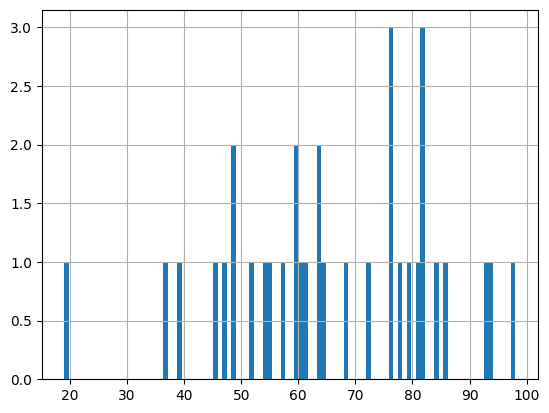

In [634]:
points = exam_results["Test Results in Points"]
points.hist(bins=100)

In [635]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
yz45eryf,57.5
il71ywod,94.0
ib35olyr,64.0
eb37yzyp,39.0
uk68iduv,81.5


In [636]:
pass_score = 45.0
max_score = 100.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

5.0

In [637]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [638]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0]

In [639]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,90.0,100.0
1.33,85.0,89.9
1.66,80.0,84.9
2.00,75.0,79.9
2.33,70.0,74.9
2.66,65.0,69.9
3.00,60.0,64.9
3.33,55.0,59.9
3.66,50.0,54.9


In [640]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
yz45eryf,57.5,3.33
il71ywod,94.0,1.00
ib35olyr,64.0,3.00
eb37yzyp,39.0,5.00
uk68iduv,81.5,1.66
ek23yboj,68.5,2.66
ez72oxib,81.0,1.66
sa58juwu,93.0,1.00
al11ytyw,81.5,1.66


<Axes: >

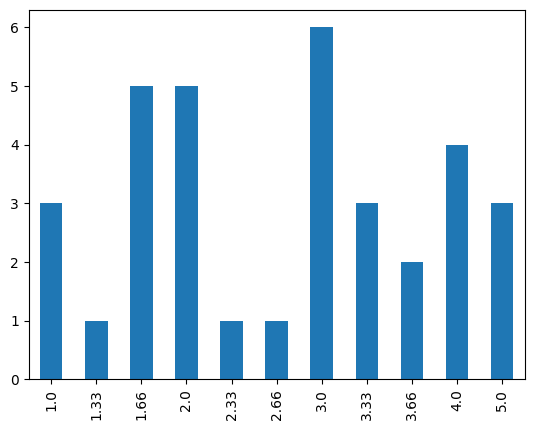

In [641]:
# Without Bonus

points["grade"].value_counts().sort_index().plot(kind="bar")

In [642]:
bonus_points = pd.read_csv("/Users/abelluc/Code/ads_exercise/total_score/2023_total.csv")
bonus_points.set_index("identifier", inplace=True)
bonus_points.index.names = ["student_id"]
bonus_points

,student_id,score_percent
student_id,,
za07ryma,AhmedSofan10,92.0
ju47kato,ArefehRh,51.0
ix31ipix,Ashikluffy,1.0
sy23hoza,Chamutalcast,9.0
na30dopa,Dan-github16,1.0
go63gaxo,EmilyKratsch,59.0
lo27cyru,FA-538,42.0
al11ytyw,Gschosi,100.0
aq28onip,Jonas185,24.0


In [643]:
# join points and bonus_points

points = points.join(bonus_points)
points.drop("student_id", axis=1, inplace=True)
points

,points,grade,score_percent
student_id,,,
yz45eryf,57.5,3.33,NaN
il71ywod,94.0,1.00,38.0
ib35olyr,64.0,3.00,82.0
eb37yzyp,39.0,5.00,9.0
uk68iduv,81.5,1.66,100.0
ek23yboj,68.5,2.66,NaN
ez72oxib,81.0,1.66,75.0
sa58juwu,93.0,1.00,9.0
al11ytyw,81.5,1.66,100.0


In [644]:
# replace values in score_percent with 0.33, 0.66, 1.0
points["bonus"] = np.zeros(len(points))

points["bonus"][points["score_percent"] >= 95] = 0.66
points["score_percent"][points["score_percent"] >= 95] = 0

points["bonus"][points["score_percent"] >= 90] = 0.33

# replace nan with 0
points.fillna(0, inplace=True)

points.drop("score_percent", axis=1, inplace=True)
points

,points,grade,bonus
student_id,,,
yz45eryf,57.5,3.33,0.00
il71ywod,94.0,1.00,0.00
ib35olyr,64.0,3.00,0.00
eb37yzyp,39.0,5.00,0.00
uk68iduv,81.5,1.66,0.66
ek23yboj,68.5,2.66,0.00
ez72oxib,81.0,1.66,0.00
sa58juwu,93.0,1.00,0.00
al11ytyw,81.5,1.66,0.66


In [645]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

,points,grade,bonus,grade_with_bonus
student_id,,,,
yz45eryf,57.5,3.33,0.00,3.33
il71ywod,94.0,1.00,0.00,1.00
ib35olyr,64.0,3.00,0.00,3.00
eb37yzyp,39.0,5.00,0.00,5.00
uk68iduv,81.5,1.66,0.66,1.00
ek23yboj,68.5,2.66,0.00,2.66
ez72oxib,81.0,1.66,0.00,1.66
sa58juwu,93.0,1.00,0.00,1.00
al11ytyw,81.5,1.66,0.66,1.00


In [648]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
il71ywod,94.0,1.0,0.0,1.0
ik94foow,98.0,1.0,0.0,1.0
sa58juwu,93.0,1.0,0.0,1.0
ly87muro,85.5,1.3,0.7,1.0
za07ryma,82.0,1.7,0.3,1.3
uk68iduv,81.5,1.7,0.7,1.0
ez72oxib,81.0,1.7,0.0,1.7
al11ytyw,81.5,1.7,0.7,1.0
yp69ejot,84.0,1.7,0.7,1.0


In [649]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,34.000000,34.000000,34.000000,34.000000
mean,65.970588,2.767647,0.235294,2.544118
std,18.023109,1.159080,0.330181,1.310607
min,19.000000,1.000000,0.000000,1.000000
25%,54.250000,1.775000,0.000000,1.300000
50%,64.250000,3.000000,0.000000,2.850000
75%,80.625000,3.600000,0.700000,3.300000
max,98.000000,5.000000,0.700000,5.000000


<Axes: >

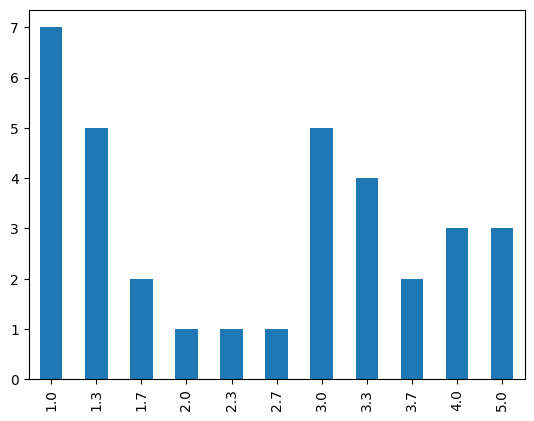

In [650]:
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [651]:
# save to csv
points.to_csv(exam_result_path.joinpath("ADS_Exam_2023_results_final.csv"))